In [177]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool

In [178]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

In [179]:
class DataLoader:
    def __init__(self, countries, max_count = (0, 5)):
        self.countries = countries
        self.max_count = max_count

    def get_dataset(self, folder_path):
        data = pd.DataFrame()
        for country in self.countries:
            for count in range(*self.max_count):
                path = folder_path + f"{country}_{count}.csv"
                try:
                    df = pd.read_csv(path)
                    data = pd.concat([data, df])
                except Exception as e:
                    print(f"Нет директории {path}: {e}")
        data["war_status"] = data["war_status"].astype(int)
        return data

In [180]:
loader = DataLoader(["ENG", "USA", "RUS", "AUS"], (1, 6))
data = loader.get_dataset("data/")

Нет директории data/ENG_4.csv: [Errno 2] No such file or directory: 'data/ENG_4.csv'
Нет директории data/ENG_5.csv: [Errno 2] No such file or directory: 'data/ENG_5.csv'
Нет директории data/USA_2.csv: Error tokenizing data. C error: Expected 42 fields in line 141, saw 83

Нет директории data/USA_4.csv: [Errno 2] No such file or directory: 'data/USA_4.csv'
Нет директории data/USA_5.csv: [Errno 2] No such file or directory: 'data/USA_5.csv'
Нет директории data/RUS_4.csv: [Errno 2] No such file or directory: 'data/RUS_4.csv'
Нет директории data/RUS_5.csv: [Errno 2] No such file or directory: 'data/RUS_5.csv'
Нет директории data/AUS_4.csv: [Errno 2] No such file or directory: 'data/AUS_4.csv'
Нет директории data/AUS_5.csv: [Errno 2] No such file or directory: 'data/AUS_5.csv'


In [181]:
cat_cols = ["goverement", "most_popular_party", "war_status"]
num_cols = ["population", "money_activity", "industrial_level", "subside_percent", "rentability", "subside_pct", "diversification", "gold_income",\
             "country_savings", "bank_savings", "population_savings", "money_mass", "all_employemenent", "all_free_work_places", "fabric_worker_salary",\
             "capitalist_salary", "literacy", "military_budget", "naval_budget", "army_innov", "naval_innov", "country_size", "population_per_reg",\
             "rich_tax", "middle_tax", "poor_tax"]
all_cols = cat_cols + num_cols

In [ ]:
class DataProcessor:
    def __init__(self):
        pass

    def prepare_data(self, data: pd.DataFrame) -> pd.DataFrame:
        X = data.copy()
        X["gdp"] = X["gdp"].bfill().ffill()
        for col in num_cols:
            X[col] = X[col].fillna(0).astype(int)
        return X

In [191]:
data["gdp"].unique()

array([11441., 11504., 11708., ...,  9898., 10991., 11752.], shape=(1439,))

In [183]:
processor = DataProcessor()
data = processor.prepare_data(data)
train, val = train_test_split(data, test_size = 0.1, random_state=42, shuffle=True)
X = train[all_cols]
X_val = val[all_cols]
y = np.log1p(train["gdp"])
y_val = np.log1p(val["gdp"])

In [184]:
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    loss_function="RMSE",
    verbose=100,
    eval_metric="RMSE",
    early_stopping_rounds=100,
)

In [185]:
train_data = Pool(X, y, cat_features=cat_cols)
val_data = Pool(X_val, y_val, cat_features=cat_cols)

In [186]:
model.fit(train_data, eval_set=val_data)

CatBoostError: catboost/libs/metrics/metric.cpp:7032: metric/loss-function RMSE does not allow nan values in target data

In [ ]:
test_loader = DataLoader(["FRA"], (1, 3))
test = test_loader.get_dataset("data/")

In [ ]:
X_test = test[all_cols]
y_test = np.log1p(test["gdp"])

In [ ]:
prediction = model.predict(X_test)

In [ ]:
print(root_mean_squared_error(np.expm1(y_test), np.expm1(prediction)))

1656.7671166285265


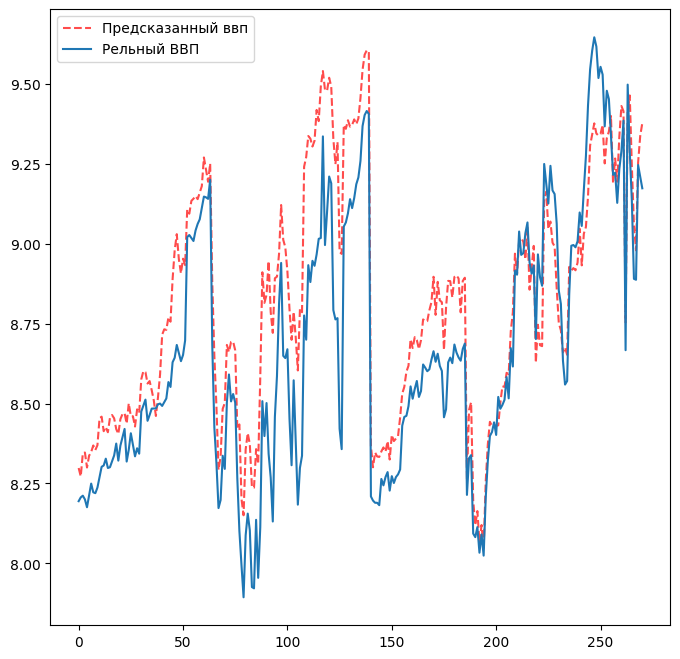

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.plot(prediction, "r--", label = "Предсказанный ВВП", alpha = 0.7)
plt.plot(y_test.to_numpy(), label = "Рельный ВВП") 
plt.legend()
plt.show()

In [ ]:
import shap

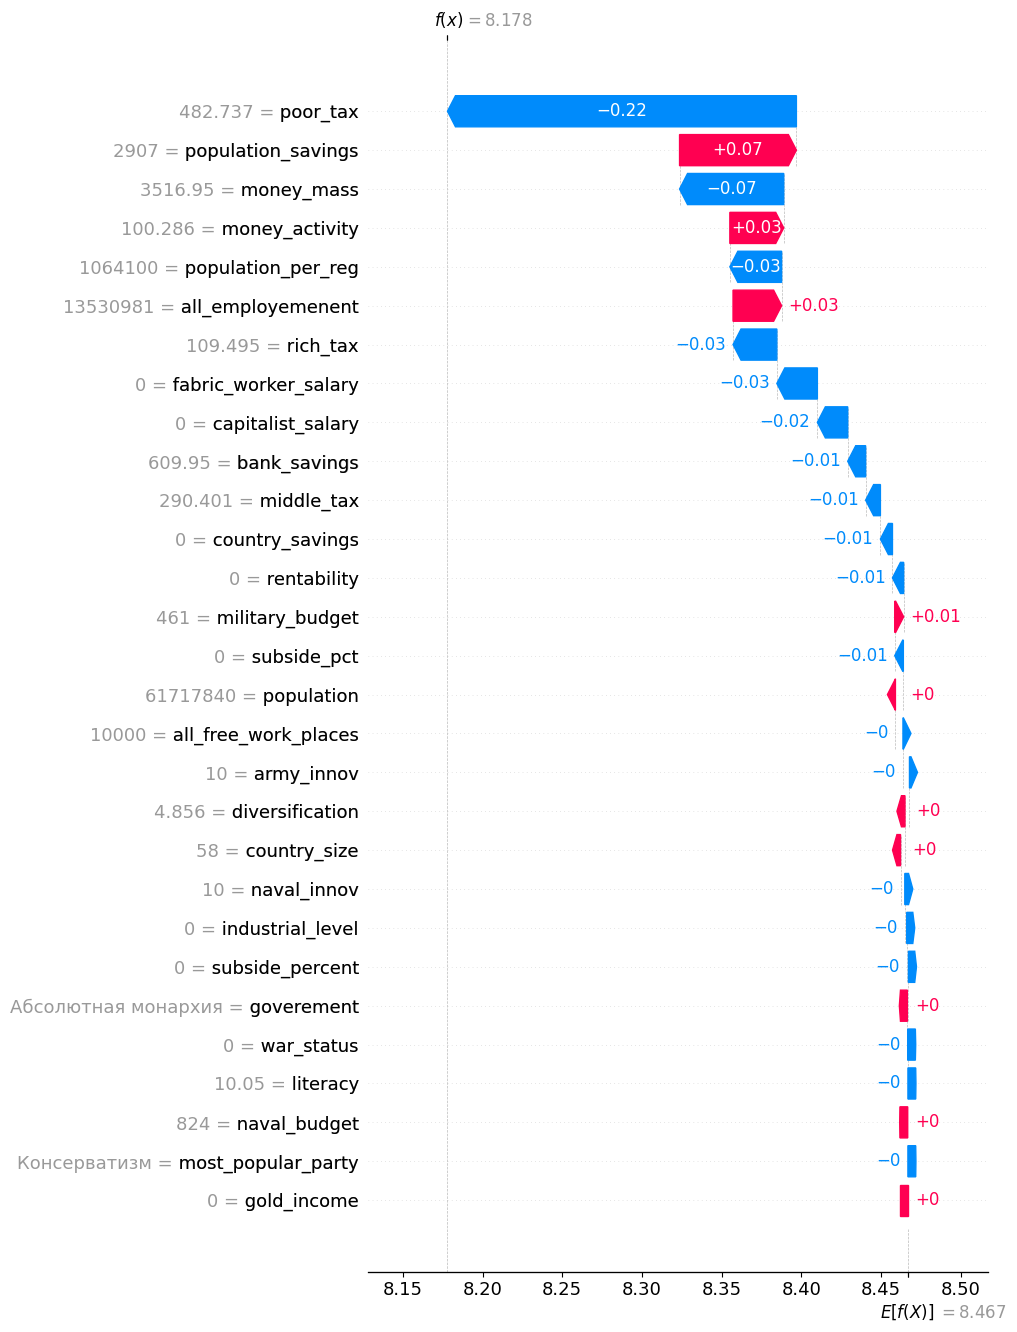

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)
shap.plots.waterfall(shap_values[1], 100)